# Projeto de Matemática para Ciência de Dados — Rede Neural Generalizada

**Base:** `exemplo4.py` (aula de 21/08/2026)
**Entrega:** 26/09/2026

Este notebook parte do `exemplo4.py` e generaliza a mesma rede para um número arbitrário de camadas,
mantendo exatamente a mesma matemática (soma ponderada, ativação, erro, regra da cadeia, gradiente
descendente) — só reescrita em forma de matriz em vez de uma linha de código por neurônio.

**O que muda em relação ao `exemplo4.py` original:**

| Aspecto | `exemplo4.py` (original) | Esta versão |
|---|---|---|
| Base de dados | `make_moons` (duas luas) | `make_circles` (círculos concêntricos) |
| Camadas ocultas | 1 | 3 |
| Neurônios por camada | 2 → 1 (saída) | 8 → 6 → 4 → 1 (saída) |
| Ativação das ocultas | Sigmoide | ReLU |
| Ativação da saída | Sigmoide | Sigmoide (mantida) |

**Por quê:** `make_circles` deixa evidente por que uma rede sem não-linearidade fracassa — nenhuma reta
separa um círculo de dentro do outro. Três camadas escondidas testam de verdade a generalização da
fórmula para qualquer número de camadas. ReLU nas camadas ocultas evita que o gradiente encolha ao
atravessar uma rede mais profunda (*vanishing gradient*), problema que a sigmoide sofre. A saída
continua sigmoide porque o problema é classificação binária e precisamos de uma probabilidade entre 0 e 1.

Ao final, validamos a implementação manual contra um modelo equivalente em Keras.


## 0. Instalando as bibliotecas

Rode esta célula primeiro, uma única vez. Ela instala as bibliotecas no mesmo ambiente Python que o
Jupyter está usando agora — isso evita o erro `ModuleNotFoundError`, que costuma acontecer quando o
pacote foi instalado num Python diferente do que o notebook está rodando (por exemplo, pelo terminal,
mas com o VS Code usando outro interpretador). Se todas já estiverem instaladas, a célula só vai
mostrar "Requirement already satisfied" e não faz nada de mais.

In [1]:
%pip install -q numpy matplotlib scikit-learn tensorflow

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Base de dados

`make_circles` gera pontos formando dois círculos concêntricos — um problema não-linearmente separável:
nenhuma reta consegue separar o círculo interno do externo.

Matplotlib is building the font cache; this may take a moment.


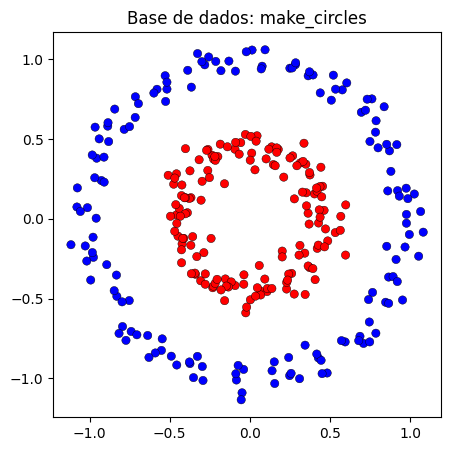

300 pontos, 150 da classe 0 (azul), 150 da classe 1 (vermelho)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

np.random.seed(42)

X, Y = make_circles(n_samples=300, noise=0.06, factor=0.45, random_state=42)

cores = ['blue' if k == 0 else 'red' for k in Y]
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=cores, edgecolor='k', linewidth=0.3)
plt.title('Base de dados: make_circles')
plt.savefig('circulos.png', dpi=150)
plt.show()

print(f'{len(X)} pontos, {sum(Y==0)} da classe 0 (azul), {sum(Y==1)} da classe 1 (vermelho)')

## 1. Base de dados

A base de dados utilizada foi gerada pela função make_blobs,da biblioteca Scikit-learn, que gera  aglomerados (blobs) de pontos distribuidos de forma gaussiana. Essa base serve principalmente para testar e demonstrar algoritmos de aprendizado de máquina voltados para agrupamento (clustering, como o K-Means) e classificação.

Com o objetivo de criar um cenário mais desafiador e próximo da complexidade de dados reais, a base de dados foi configurada com 1000 amostras e um desvio padrão elevado. Isso torna os dados mais dispersos ao redor do cluster e, consequentemente, mais misturados e sobrepostos uns aos outros. O resultado é um conjunto de dados mais realista e, ao mesmo tempo, difícil para algoritmos de aprendizado de máquina identificarem divisões exatas entre as classes.

Além disso, a estrutura original do problema, que era multinomial, foi convertida em problema de classificação binária, mapeando a classe 0 como **classe positiva**, enquanto as classes 1 e 2 foram agrupadas para representar a **classe negativa**. A respectiva fusão tornou esse conjunto de dados desbalanceado, pois a classe negativa passou a concentrar o dobro de instâncias em relação á classe positiva, e, consequentemente, eleva o rigor dos testes, exigindo maior robustez dos modelos avaliados.

Total Positivo: 334
Total Negativo: 666


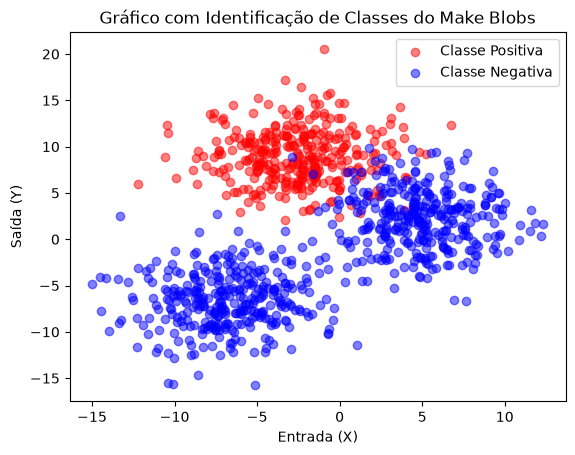

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Gerar os dados
X, Y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42, cluster_std=3.0)

# 2. Binarização: 1 se for classe 0; 0 caso contrário
Y = np.where(Y == 0, 1, 0)

# Configurações do gráfico
plt.title('Gráfico com Identificação de Classes do Make Blobs')
plt.xlabel('Entrada (X)')
plt.ylabel('Saída (Y)')

# 3. Separar e plotar a Classe Negativa (Y == 0)
plt.scatter(
    X[Y == 1, 0], X[Y == 1, 1], 
    label='Classe Positiva', c='red', alpha=0.5
)

# 4. Separar e plotar a Classe Positiva (Y == 1)
plt.scatter(
    X[Y == 0, 0], X[Y == 0, 1], 
    label='Classe Negativa', c='blue', alpha=0.5
)

# 5. legenda
plt.legend(loc='upper right')

# Exibir os prints e o gráfico
print("Total Positivo:", np.sum(Y == 1))
print("Total Negativo:", np.sum(Y == 0))
plt.show()

## 2. Funções de ativação

- **Sigmoide**: $\sigma(v) = \dfrac{1}{1+e^{-v}}$, com derivada $\sigma'(v) = \sigma(v)(1-\sigma(v))$ — usada
  só na saída, porque comprime o resultado entre 0 e 1 (interpretável como probabilidade).
- **ReLU**: $\text{ReLU}(v) = \max(0, v)$, com derivada $1$ se $v>0$ e $0$ caso contrário — usada nas 3
  camadas escondidas, porque sua derivada não encolhe para entradas positivas, evitando o vanishing
  gradient numa rede mais profunda que a original.

In [3]:
def sigmoide(v):
    return 1 / (1 + np.exp(-v))

def sigmoide_deriv(v):
    s = sigmoide(v)
    return s * (1 - s)

def relu(v):
    return np.maximum(0, v)

def relu_deriv(v):
    return (v > 0).astype(float)

print('sigmoide(0) =', sigmoide(0), '  relu(-2) =', relu(-2), '  relu(3) =', relu(3))

sigmoide(0) = 0.5   relu(-2) = 0   relu(3) = 3


## 3. Arquitetura generalizada em matrizes

Para uma rede com $N$ camadas, definimos $\mathbf{a}^{(0)} = \mathbf{x}$ e, para cada camada
$l=1,\dots,N$:

$$\mathbf{v}^{(l)} = W^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} \qquad \mathbf{a}^{(l)} = \sigma^{(l)}(\mathbf{v}^{(l)})$$

Isso é o mesmo cálculo do `exemplo4.py` (que escrevia `s00 = w0[0,0]*x[0]`, `s01 = w0[0,1]*x[1]`,
`v0 = s00+s01+b0[0]` linha por linha para cada neurônio), só que a matriz $W^{(l)}$ faz todas essas
multiplicações e somas de uma vez, para qualquer número de neurônios.

Nossa arquitetura é $[2, 8, 6, 4, 1]$: 2 entradas, três camadas escondidas (8, 6, 4 neurônios), 1 saída.
Em código (com exemplos em linha, não em coluna), cada $W^{(l)}$ tem forma `(tamanhos[l], tamanhos[l+1])`.

In [4]:
def inicializar_pesos(tamanhos, seed=0):
    rng = np.random.RandomState(seed)
    L = len(tamanhos) - 1
    W = [rng.randn(tamanhos[i], tamanhos[i+1]) * 0.5 for i in range(L)]
    b = [np.zeros(tamanhos[i+1]) for i in range(L)]
    return W, b

tamanhos = [2, 8, 6, 4, 1]
W, b = inicializar_pesos(tamanhos, seed=0)
for i, (Wi, bi) in enumerate(zip(W, b)):
    print(f'camada {i+1}: W{i+1}.shape = {Wi.shape}   b{i+1}.shape = {bi.shape}')

camada 1: W1.shape = (2, 8)   b1.shape = (8,)
camada 2: W2.shape = (8, 6)   b2.shape = (6,)
camada 3: W3.shape = (6, 4)   b3.shape = (4,)
camada 4: W4.shape = (4, 1)   b4.shape = (1,)


## 4. Forward pass generalizado

Um laço `for` percorre as camadas — nenhuma é tratada como caso especial. As três primeiras usam ReLU,
a última usa sigmoide.

In [5]:
ativ = [relu, relu, relu, sigmoide]
ativ_deriv = [relu_deriv, relu_deriv, relu_deriv, sigmoide_deriv]

def forward(X, W, b):
    a = X
    cache_v, cache_a = [], [a]
    for l in range(len(W)):
        v = a @ W[l] + b[l]
        a = ativ[l](v)
        cache_v.append(v)
        cache_a.append(a)
    return a, cache_v, cache_a

yhat, cache_v, cache_a = forward(X, W, b)
print('formato da saida:', yhat.shape)
print('primeiras 5 predicoes (pesos ainda aleatorios):', yhat[:5].ravel())

formato da saida: (300, 1)
primeiras 5 predicoes (pesos ainda aleatorios): [0.49988611 0.50462743 0.5        0.5        0.50230456]


/var/folders/r8/drfpnd8s20zdvn7xfv0l7d7h0000gn/T/ipykernel_93417/2621087051.py:8: RuntimeWarning: divide by zero encountered in matmul
  v = a @ W[l] + b[l]
/var/folders/r8/drfpnd8s20zdvn7xfv0l7d7h0000gn/T/ipykernel_93417/2621087051.py:8: RuntimeWarning: overflow encountered in matmul
  v = a @ W[l] + b[l]
/var/folders/r8/drfpnd8s20zdvn7xfv0l7d7h0000gn/T/ipykernel_93417/2621087051.py:8: RuntimeWarning: invalid value encountered in matmul
  v = a @ W[l] + b[l]


## 5. Função de perda

O `exemplo4.py` usa erro quadrático (`L = 1/2 * (e ** 2)`). Com saída sigmoide isso trava o treino: a
derivada fica $(\hat y - y)\,\hat y(1-\hat y)$ — o produto que aparece na linha
`grad_v2 = grad_y2 * y2 * (1 - y2)` — e o fator $\hat y(1-\hat y)$ vai a zero justamente quando a rede erra
com confiança. Trocamos pela entropia cruzada binária, que vem do logaritmo da verossimilhança
$\hat y^{\,y}(1-\hat y)^{1-y}$:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\Big[\,y_i\ln \hat y_i + (1-y_i)\ln(1-\hat y_i)\,\Big]
\qquad
\frac{\partial L}{\partial \hat y_i} = \frac{1}{n}\cdot\frac{\hat y_i - y_i}{\hat y_i(1-\hat y_i)}$$

Guarde o denominador $\hat y_i(1-\hat y_i)$: na Seção 6 ele cancela com a derivada da sigmoide.

Dois cuidados no código:

- **$\ln(0) = -\infty$** — se a sigmoide saturar em `0.0` ou `1.0`, a perda vira `nan`. Limitamos $\hat y$ ao
  intervalo $[\varepsilon,\, 1-\varepsilon]$ antes do logaritmo.
- **`Y` precisa ser coluna `(n, 1)`** — com formato `(n,)`, `yhat - Y` não dá erro: o NumPy faz broadcasting,
  devolve uma matriz `(n, n)` e o treino roda até o fim calculando lixo.

O original soma os gradientes dos 100 exemplos; nós tiramos a média. Mesma direção, passo $n$ vezes menor —
a `taxa` de lá não é comparável com a nossa.

In [ ]:
# Y vira matriz coluna (n, 1) para casar com o formato de yhat e evitar broadcasting silencioso
Y = Y.reshape(-1, 1).astype(float)

EPS = 1e-12  # margem que impede ln(0)

def perda(Y, Yhat):
    """Entropia cruzada binaria media: -1/n * sum[ y*ln(yhat) + (1-y)*ln(1-yhat) ]."""
    Yhat = np.clip(Yhat, EPS, 1 - EPS)
    return -np.mean(Y * np.log(Yhat) + (1 - Y) * np.log(1 - Yhat))


def acuracia(Y, Yhat):
    """Fracao de acertos, usando 0.5 como limiar de decisao."""
    return np.mean((Yhat >= 0.5).astype(float) == Y)


# Sanidade: com os pesos ainda aleatorios a rede nao sabe nada, entao a perda
# deve ficar perto de ln(2) ~ 0.693 -- o valor de quem "chuta" 0.5 para todo mundo.
yhat, cache_v, cache_a = forward(X, W, b)

print(f'Y.shape = {Y.shape}   yhat.shape = {yhat.shape}')
print(f'perda inicial = {perda(Y, yhat):.4f}   (referencia do chute: ln(2) = {np.log(2):.4f})')
print(f'acuracia inicial = {acuracia(Y, yhat):.4f}')

# Os dois casos extremos, para ver a assimetria da entropia cruzada:
print(f'\nacerto confiante  (y=1, yhat=0.99): perda = {perda(np.array([[1.0]]), np.array([[0.99]])):.4f}')
print(f'erro   confiante  (y=1, yhat=0.01): perda = {perda(np.array([[1.0]]), np.array([[0.01]])):.4f}')

## 6. Backward generalizado

A mesma regra da cadeia do `exemplo4.py`, que a escrevia com uma variável por peso (`grad_s00`, `grad_w0[0,0]`,
…), só que agora de uma vez para qualquer profundidade. A peça central é
$\delta^{(l)} = \partial L/\partial \mathbf{v}^{(l)}$, o erro que chega à entrada da camada $l$ — de posse
dele, os dois gradientes que queremos saem direto:

$$\frac{\partial L}{\partial W^{(l)}} = \big(A^{(l-1)}\big)^{\!\top} \Delta^{(l)}
\qquad
\frac{\partial L}{\partial \mathbf{b}^{(l)}} = \sum_{i=1}^{n} \Delta^{(l)}_{i,:}$$

(maiúsculas = os $n$ exemplos empilhados em linhas; o viés soma sobre os exemplos porque é o mesmo para todos.)

Na saída, a derivada da perda encontra a da sigmoide e o denominador cancela:

$$\delta^{(N)} = \underbrace{\frac{1}{n}\cdot\frac{\hat y - y}{\hat y(1-\hat y)}}_{\text{perda}}\cdot\underbrace{\hat y(1-\hat y)}_{\sigma'(v^{(N)})} = \frac{\hat y - y}{n}$$

Sobra o erro puro, sem nenhum fator que possa saturar — é para isso que serve a entropia cruzada. Daí para
trás, camada a camada:

$$\delta^{(l)} = \Big(\delta^{(l+1)}\,\big(W^{(l+1)}\big)^{\!\top}\Big)\;\odot\;\sigma^{(l)\prime}\!\big(v^{(l)}\big)$$

São duas coisas: $W^\top$ **redistribui** o erro para trás (a mesma matriz do forward, transposta), e o
$\odot$ — produto elemento a elemento — **filtra** pelo quanto cada neurônio reagiu. Com ReLU, quem estava
desligado não recebe gradiente nenhum.

Atenção aos índices: `cache_a[l]` é $a^{(l)}$, mas `cache_v[l]` é $v^{(l+1)}$ — deslocado de 1. No laço, `l`
é índice de lista e corresponde à camada $l+1$ da matemática.

In [ ]:
def backward(Y, W, b, cache_v, cache_a):
    """Gradientes da entropia cruzada em relacao a W e b, para qualquer numero de camadas.

    Devolve (gW, gb), com gW[l].shape == W[l].shape e gb[l].shape == b[l].shape.
    """
    L = len(W)                  # numero de camadas
    n = Y.shape[0]              # numero de exemplos
    gW = [None] * L
    gb = [None] * L

    Yhat = cache_a[-1]          # saida do forward = a^(N)

    # Passo 1: delta da ultima camada.
    # O denominador yhat(1-yhat) da derivada da entropia cruzada cancela com
    # sigmoide_deriv, sobrando o erro puro. Dividimos por n porque a perda e a media.
    delta = (Yhat - Y) / n

    # Passo 2: percorre as camadas de tras para frente.
    for l in reversed(range(L)):
        # Gradientes desta camada, usando o delta que ja chegou aqui.
        gW[l] = cache_a[l].T @ delta        # (tam[l], n) @ (n, tam[l+1])
        gb[l] = delta.sum(axis=0)           # soma sobre os exemplos

        # Propaga o delta para a camada anterior (nao ha o que propagar antes da 1a).
        if l > 0:
            erro_redistribuido = delta @ W[l].T          # volta pela matriz transposta
            delta = erro_redistribuido * ativ_deriv[l - 1](cache_v[l - 1])  # filtra (Hadamard)

    return gW, gb


# Teste de formato: e o jeito mais barato de pegar erro de transposicao.
yhat, cache_v, cache_a = forward(X, W, b)
gW, gb = backward(Y, W, b, cache_v, cache_a)

for l in range(len(W)):
    ok_W = gW[l].shape == W[l].shape
    ok_b = gb[l].shape == b[l].shape
    print(f'camada {l+1}: gW{l+1} {gW[l].shape} vs W{l+1} {W[l].shape} -> {ok_W}   |   '
          f'gb{l+1} {gb[l].shape} vs b{l+1} {b[l].shape} -> {ok_b}')

assert all(gW[l].shape == W[l].shape for l in range(len(W)))
assert all(gb[l].shape == b[l].shape for l in range(len(b)))
print('\nTodos os formatos batem.')

## 7. Verificação numérica do gradiente

Os formatos baterem não prova nada: um sinal trocado passa despercebido e a rede apenas treina mal. O teste
de verdade é comparar cada gradiente do `backward` com a diferença central, que sai da subtração de duas
expansões de Taylor (o termo em $f''$ cancela, deixando erro $O(\varepsilon^2)$):

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\varepsilon) - L(\theta-\varepsilon)}{2\varepsilon}
\qquad
\text{erro} = \frac{|\,g_{\text{analítico}} - g_{\text{numérico}}\,|}{|g_{\text{analítico}}| + |g_{\text{numérico}}|}$$

Abaixo de $10^{-7}$ considera-se correto. O método é caro demais para treinar — uma rede inteira avaliada
duas vezes por parâmetro —, e é exatamente por isso que o backpropagation existe.

O teste principal roda numa rede pequena só com sigmoide, porque a ReLU não é derivável em $v=0$: ao somar
$\varepsilon$, alguns exemplos cruzam a quina e mudam de regime, e o numérico capta um salto que o analítico
não vê. Repetimos na rede real para ver o efeito — os parâmetros que discordam são os da quina, não bugs.

In [ ]:
def gradiente_numerico(param, idx, Xd, Yd, Wd, bd, eps=1e-5):
    """Derivada de L em relacao a param[idx], pela diferenca central."""
    original = param[idx]
    param[idx] = original + eps
    L_mais = perda(Yd, forward(Xd, Wd, bd)[0])
    param[idx] = original - eps
    L_menos = perda(Yd, forward(Xd, Wd, bd)[0])
    param[idx] = original                       # desfaz a perturbacao
    return (L_mais - L_menos) / (2 * eps)


def verificar_gradiente(Xd, Yd, Wd, bd):
    """Compara backward vs diferenca central em TODOS os parametros. Devolve os erros relativos."""
    _, cv, ca = forward(Xd, Wd, bd)
    gWd, gbd = backward(Yd, Wd, bd, cv, ca)

    erros = []
    for l in range(len(Wd)):
        for i in range(Wd[l].shape[0]):
            for j in range(Wd[l].shape[1]):
                ana = gWd[l][i, j]
                num = gradiente_numerico(Wd[l], (i, j), Xd, Yd, Wd, bd)
                erros.append(abs(ana - num) / max(1e-12, abs(ana) + abs(num)))
        for j in range(bd[l].shape[0]):
            ana = gbd[l][j]
            num = gradiente_numerico(bd[l], (j,), Xd, Yd, Wd, bd)
            erros.append(abs(ana - num) / max(1e-12, abs(ana) + abs(num)))
    return np.array(erros)


# --- Teste 1: rede pequena e lisa (sigmoide em todas as camadas) ---
# E aqui que o backward e de fato validado: a funcao e derivavel em todo ponto,
# entao qualquer discrepancia acima de 1e-7 seria erro de matematica.
rng = np.random.RandomState(7)
X_teste = rng.randn(20, 3)
Y_teste = rng.randint(0, 2, (20, 1)).astype(float)
W_teste, b_teste = inicializar_pesos([3, 5, 4, 1], seed=3)

ativ_original, ativ_deriv_original = ativ, ativ_deriv
try:
    ativ = [sigmoide] * 3                    # troca temporaria: rede lisa
    ativ_deriv = [sigmoide_deriv] * 3
    erros_lisa = verificar_gradiente(X_teste, Y_teste, W_teste, b_teste)
finally:
    ativ, ativ_deriv = ativ_original, ativ_deriv_original   # restaura a rede real

print(f'Teste 1 - rede lisa [3,5,4,1], {len(erros_lisa)} parametros')
print(f'  erro relativo maximo: {erros_lisa.max():.3e}')
print(f'  erro relativo medio : {erros_lisa.mean():.3e}')
print('  ->', 'BACKWARD CORRETO' if erros_lisa.max() < 1e-7 else 'HA ALGO ERRADO')

# --- Teste 2: a rede real, com ReLU ---
# Aqui o maximo NAO e a metrica certa: a quina da ReLU em v=0 faz alguns parametros
# discordarem por construcao. Olhamos a mediana e a fracao dentro da tolerancia.
erros_relu = verificar_gradiente(X, Y, W, b)
n_fora = int(np.sum(erros_relu >= 1e-7))

print(f'\nTeste 2 - rede real {tamanhos} com ReLU, {len(erros_relu)} parametros')
print(f'  mediana do erro relativo: {np.median(erros_relu):.3e}')
print(f'  dentro de 1e-7          : {len(erros_relu) - n_fora}/{len(erros_relu)} '
      f'({100*(1 - n_fora/len(erros_relu)):.1f}%)')
print(f'  fora                    : {n_fora} parametros que caem na quina da ReLU,')
print('                             onde a derivada nao existe (ver explicacao acima)')

Próximos passos
- Treinamento (gradiente descendente em lote completo)
- Analisar resultados (curva de perda e fronteira de decisão)
- Validação cruzada com Keras
- Conclusão